In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

# Load CSV
df = pd.read_csv("telco_churn.csv")

df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape, df.dtypes


((7043, 21),
 customerID           object
 gender               object
 SeniorCitizen         int64
 Partner              object
 Dependents           object
 tenure                int64
 PhoneService         object
 MultipleLines        object
 InternetService      object
 OnlineSecurity       object
 OnlineBackup         object
 DeviceProtection     object
 TechSupport          object
 StreamingTV          object
 StreamingMovies      object
 Contract             object
 PaperlessBilling     object
 PaymentMethod        object
 MonthlyCharges      float64
 TotalCharges         object
 Churn                object
 dtype: object)

In [3]:
df["Churn"].value_counts(normalize=True)


Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [4]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# How many became NaN?
df["TotalCharges"].isna().sum()


np.int64(11)

In [5]:
df = df.dropna(subset=["TotalCharges"])
df.shape


(7032, 21)

In [6]:
df.columns = df.columns.str.strip().str.replace(" ", "_")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

C:\Users\Admin\AppData\Local\Temp\ipykernel_13852\4210876480.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Churn", palette="Set2")


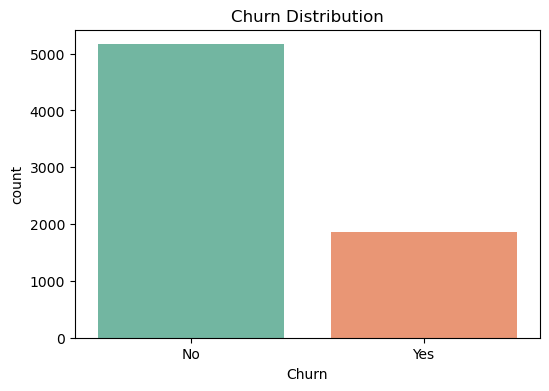

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn", palette="Set2")
plt.title("Churn Distribution")
plt.show()

df["Churn"].value_counts(normalize=True)


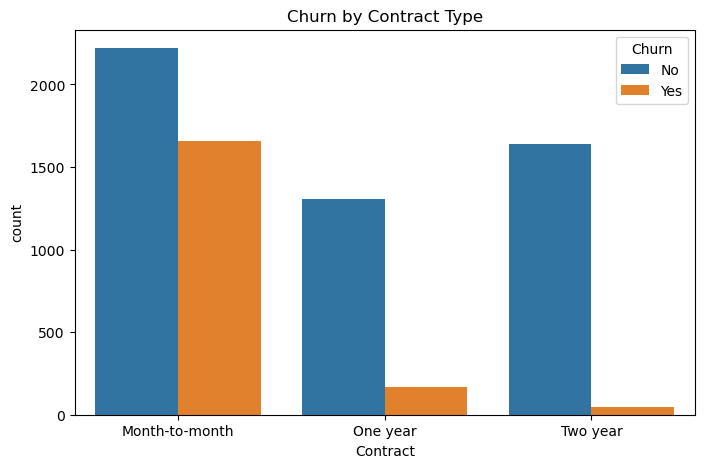

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.show()


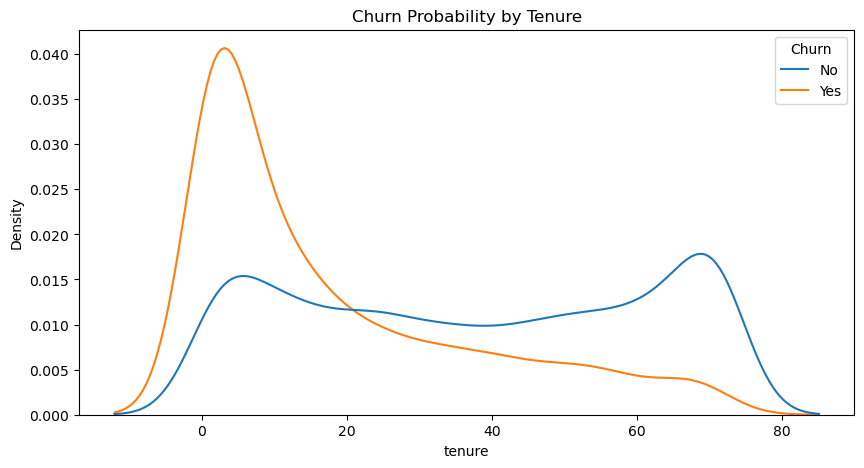

In [10]:
plt.figure(figsize=(10,5))
sns.kdeplot(data=df, x="tenure", hue="Churn", common_norm=False)
plt.title("Churn Probability by Tenure")
plt.show()


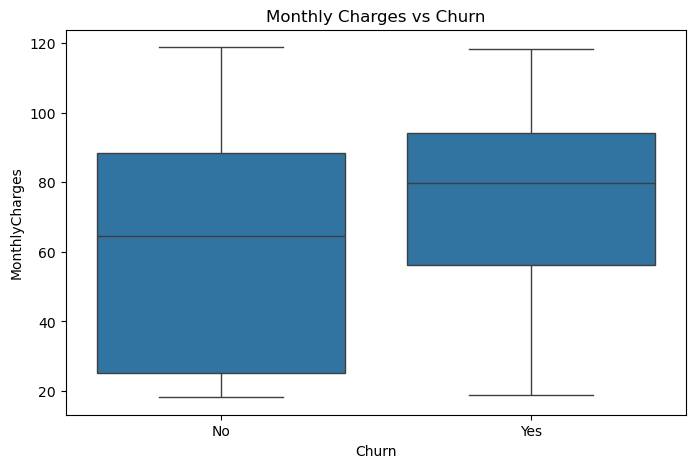

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Churn")
plt.show()

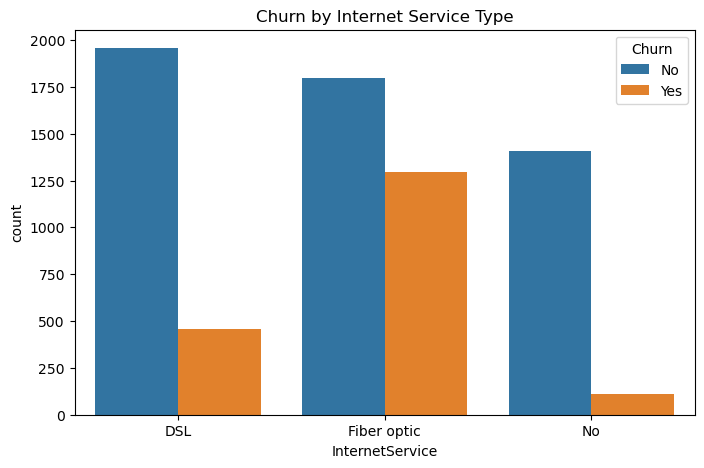

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Churn by Internet Service Type")
plt.show()


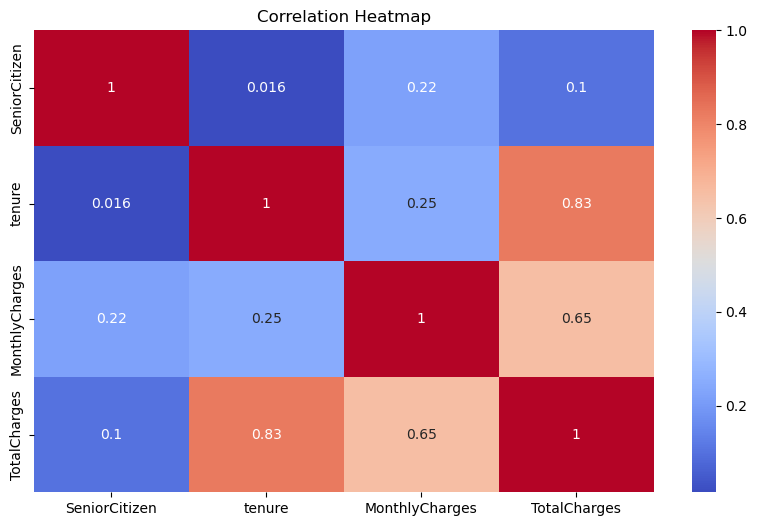

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [14]:
service_cols = [
    "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies"
]

df["ServiceCount"] = df[service_cols].apply(lambda row: 
                    sum(row == "Yes") if "Yes" in row.values else 0, axis=1)

df["ServiceCount"].head()


0    1
1    3
2    3
3    3
4    1
Name: ServiceCount, dtype: int64

In [15]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0–1 year", "1–2 years", "2–4 years", "4–6 years"]
)


In [16]:
df["ChargesTier"] = pd.qcut(df["MonthlyCharges"], q=4, labels=["Low", "Medium", "High", "Very High"])


In [17]:
df["IsFiber"] = (df["InternetService"] == "Fiber optic").astype(int)


In [18]:
df["IsAutoPay"] = df["PaymentMethod"].str.contains("automatic", case=False).astype(int)


In [19]:
df["SeniorAlone"] = (
    (df["SeniorCitizen"] == 1) & 
    (df["Partner"] == "No") & 
    (df["Dependents"] == "No")
).astype(int)


In [20]:
df["CLTV"] = df["MonthlyCharges"] * df["tenure"]


In [21]:
df_model = df.drop(columns=["customerID"])


In [22]:
from sklearn.model_selection import train_test_split

# Work on the engineered dataframe
data = df_model.copy()

# Encode target: Yes->1, No->0
data["Churn"] = (data["Churn"] == "Yes").astype(int)

# Separate features and target
X = data.drop(columns=["Churn"])
y = data["Churn"]

X.shape, y.shape, y.mean()


((7032, 26), (7032,), np.float64(0.26578498293515357))

In [23]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_features, categorical_features


(['SeniorCitizen',
  'tenure',
  'MonthlyCharges',
  'TotalCharges',
  'ServiceCount',
  'IsFiber',
  'IsAutoPay',
  'SeniorAlone',
  'CLTV'],
 ['gender',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod',
  'TenureGroup',
  'ChargesTier'])

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.mean(), y_test.mean()

((5625, 26),
 (1407, 26),
 np.float64(0.2657777777777778),
 np.float64(0.2658137882018479))

In [25]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Preprocess: scale numeric (optional later), one-hot encode categoricals
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features),
    ]
)

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",   # handles imbalance a bit
    solver="liblinear"
)

clf_logreg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", log_reg)
])

clf_logreg

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'TenureGroup',
                                                   'ChargesTier']),
                                                 ('num', 'passthrough',
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'ServiceCount', 'IsFiber',
                                                   'IsAutoPay', 'SeniorAlone',
                                                   'CLTV'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    solver='liblinear'))])

In [26]:
clf_logreg.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'TenureGroup',
                                                   'ChargesTier']),
                                                 ('num', 'passthrough',
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'ServiceCount', 'IsFiber',
                                                   'IsAutoPay', 'SeniorAlone',
                                                   'CLTV'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    solver='liblinear'))])

In [27]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = clf_logreg.predict(X_test)
y_proba = clf_logreg.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print()
print(classification_report(y_test, y_pred, digits=3))

confusion_matrix(y_test, y_pred)


ROC-AUC: 0.8340731786862418

              precision    recall  f1-score   support

           0      0.904     0.701     0.790      1033
           1      0.490     0.794     0.606       374

    accuracy                          0.726      1407
   macro avg      0.697     0.747     0.698      1407
weighted avg      0.794     0.726     0.741      1407



array([[724, 309],
       [ 77, 297]])

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

clf_rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", rf)
])

clf_rf.fit(X_train, y_train)

rf_proba = clf_rf.predict_proba(X_test)[:, 1]
print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_proba))


Random Forest ROC-AUC: 0.8179022731155297


In [29]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(
    random_state=42,
    max_depth=6,
    learning_rate=0.05,
    max_iter=300
)

# same preprocess (one-hot + numeric passthrough)
clf_hgb = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", hgb)
])

clf_hgb.fit(X_train, y_train)

hgb_proba = clf_hgb.predict_proba(X_test)[:, 1]
print("HistGradientBoosting ROC-AUC:", roc_auc_score(y_test, hgb_proba))


C:\Users\Admin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Admin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Admin\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Admin\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

HistGradientBoosting ROC-AUC: 0.8254875214188466


In [30]:
results = {
    "LogReg": roc_auc_score(y_test, y_proba),
    "RandomForest": roc_auc_score(y_test, rf_proba),
    "HistGB": roc_auc_score(y_test, hgb_proba),
}

pd.DataFrame(results, index=["ROC_AUC"]).T.sort_values("ROC_AUC", ascending=False)


,ROC_AUC
LogReg,0.834073
HistGB,0.825488
RandomForest,0.817902


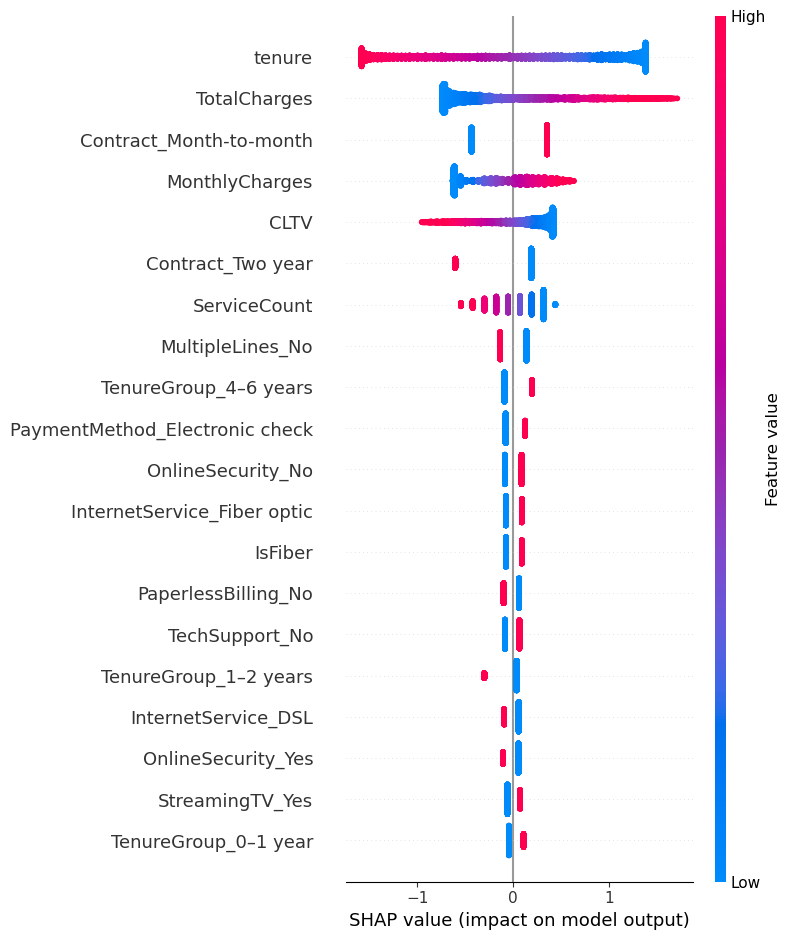

In [31]:
import shap

# Get preprocessed feature matrix
X_train_transformed = preprocess.fit_transform(X_train)

# Get feature names after one-hot encoding
ohe = preprocess.named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([cat_feature_names, numeric_features])

# Fit standalone logistic model on transformed data
logreg_shap = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="liblinear"
)
logreg_shap.fit(X_train_transformed, y_train)

# SHAP explainer
explainer = shap.LinearExplainer(logreg_shap, X_train_transformed)
shap_values = explainer.shap_values(X_train_transformed)

# SHAP summary plot
shap.summary_plot(shap_values, X_train_transformed, feature_names=all_feature_names)


## Business Recommendations

Based on the churn model and SHAP analysis:

1. Prioritise retention campaigns for **new customers (< 12 months tenure)**.
2. Incentivise **month-to-month users** to switch to annual or two-year contracts.
3. Offer **discounts or bundles** to high MonthlyCharges + Fiber optic customers.
4. Promote **AutoPay and multi-service bundles** to reduce churn risk.
5. Improve adoption of **OnlineSecurity and TechSupport**, especially for fiber users.